<a href="https://colab.research.google.com/github/Matheusbcy/-Data-Science-IA-/blob/main/Deep%20Learning/Projetos/Regress%C3%A3o/Pre%C3%A7os_de_casas_na_Calif%C3%B3rnia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import re
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [19]:
from sklearn.metrics import mean_absolute_error

In [20]:
from sklearn.preprocessing import OneHotEncoder

In [139]:
df = pd.read_csv("/content/housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [140]:
df.shape

(20640, 10)

In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [142]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [143]:
np.unique(df["ocean_proximity"])

array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
      dtype=object)

In [144]:
df.isna().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [145]:
np.mean(df["total_bedrooms"])

np.float64(537.8705525375618)

In [146]:
df = df.dropna()

In [147]:
df.shape

(20433, 10)

In [148]:
encoder = OneHotEncoder(sparse_output = False)
encoded = encoder.fit_transform(df[["ocean_proximity"]])

In [149]:
encoded_df = pd.DataFrame(
    encoded,
    columns = encoder.get_feature_names_out(["ocean_proximity"]),
    index = df.index
)

df_final = pd.concat([df.drop("ocean_proximity", axis = 1), encoded_df], axis = 1)

In [150]:
df_final.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0.0,0.0,0.0,1.0,0.0


In [151]:
y = df_final["median_house_value"]
X = df_final.drop(["median_house_value"], axis = 1)

In [152]:
from sklearn.model_selection import train_test_split
X_treinamento, X_teste, y_treinamento, y_teste = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [153]:
X_treinamento.shape, X_teste.shape

((16346, 13), (4087, 13))

In [154]:
y_treinamento.shape, y_teste.shape

((16346,), (4087,))

# Treinamento

In [37]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

# Tuning de parâmetros

In [38]:
params_dt = {
    "criterion": ["squared_error", "friedman_mse", "absolute_error"],
    "splitter": ["best", "random"],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 5, 10],
    "max_depth": [None, 5, 10, 20]
}

In [ ]:
grid_search = GridSearchCV(estimator = DecisionTreeRegressor(), param_grid = params_dt)
grid_search.fit(X_treinamento, y_treinamento)
best_params = grid_search.best_params_
best_result = grid_search.best_score_
print(best_params, best_result)

{'criterion': 'squared_error', 'max_depth': 20, 'min_samples_leaf': 10, 'min_samples_split': 5, 'splitter': 'best'} 0.7390396503229254

In [ ]:
params_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

grid_search = GridSearchCV(estimator = RandomForestRegressor(), param_grid = params_rf)
grid_search.fit(X_treinamento, y_treinamento)
best_params = grid_search.best_params_
best_result = grid_search.best_score_
print(best_params, best_result)

{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300} 0.8187573280677973

In [ ]:
params_gb = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [3, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2, 5]
}

grid_search = GridSearchCV(estimator = GradientBoostingRegressor(), param_grid = params_gb)
grid_search.fit(X_treinamento, y_treinamento)
best_params = grid_search.best_params_
best_result = grid_search.best_score_
print(best_params, best_result)

{'learning_rate': 0.2, 'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 5, 'n_estimators': 200} 0.8315953916923885

## Treinamento dos modelos

## DecisionTree

In [ ]:
tree = DecisionTreeRegressor(criterion = "squared_error", max_depth = 20, min_samples_leaf = 10, min_samples_split = 5, splitter= "best")
tree.fit(X_treinamento, y_treinamento)
prev_tree = tree.predict(X_teste)
mean_absolute_error(y_teste, prev_tree)

## RandomForest

In [ ]:
random_forest = RandomForestRegressor(max_depth = None, min_samples_leaf = 2, min_samples_split = 2, n_estimators = 300)
random_forest.fit(X_treinamento, y_treinamento)
prev_forest = random_forest.predict(X_teste)
mean_absolute_error(y_teste, prev_forest)

## Boosting

In [ ]:
boosting = GradientBoostingRegressor(learning_rate = 0.2, max_depth = 5, min_samples_leaf = 5, min_samples_split = 5, n_estimators = 200)
boosting.fit(X_treinamento, y_treinamento)
prev_boosting = boosting.predict(X_teste)
mean_absolute_error(y_teste, prev_boosting)

# Farei a normalização dos valores números para tentar adquiri resultados melhores

In [155]:
from sklearn.preprocessing import MinMaxScaler
X_scaled = MinMaxScaler(feature_range=(0, 1))
X_treinamento_scaled = X_scaled.fit_transform(X_treinamento)

X_teste_scaled = X_scaled.transform(X_teste)

## Decision Tree normalizado

In [41]:
tree = DecisionTreeRegressor(criterion = "squared_error", max_depth = 20, min_samples_leaf = 10, min_samples_split = 5, splitter= "best")
tree.fit(X_treinamento_scaled, y_treinamento)
prev_tree = tree.predict(X_teste_scaled)
mean_absolute_error(y_teste, prev_tree)

37403.259759704546

## Random Forest Normalizado

In [42]:
random_forest = RandomForestRegressor(max_depth = None, min_samples_leaf = 2, min_samples_split = 2, n_estimators = 300)
random_forest.fit(X_treinamento_scaled, y_treinamento)
prev_forest = random_forest.predict(X_teste_scaled)
mean_absolute_error(y_teste, prev_forest)

31436.74655261082

## Boosting Normalizado

In [43]:
boosting = GradientBoostingRegressor(learning_rate = 0.2, max_depth = 5, min_samples_leaf = 5, min_samples_split = 5, n_estimators = 200)
boosting.fit(X_treinamento_scaled, y_treinamento)
prev_boosting = boosting.predict(X_teste_scaled)
mean_absolute_error(y_teste, prev_boosting)

31911.10018011966

# Treinando rede neural

In [44]:
from sklearn.neural_network import MLPRegressor

In [45]:
mlp_regressor = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=2000,
    random_state=42,
    verbose=True
)

In [46]:
mlp_regressor.fit(X_treinamento, y_treinamento)

Iteration 1, loss = 25352897859.13128662
Iteration 2, loss = 13493678329.26043892
Iteration 3, loss = 12633148863.39907646
Iteration 4, loss = 11793161367.18832588
Iteration 5, loss = 10446995480.78986168
Iteration 6, loss = 8356081199.51525116
Iteration 7, loss = 6306622801.53856087
Iteration 8, loss = 5514124818.00847435
Iteration 9, loss = 5337800649.43438816
Iteration 10, loss = 5253383811.66144466
Iteration 11, loss = 5144658096.26544952
Iteration 12, loss = 5051694348.38913441
Iteration 13, loss = 4961197867.70828152
Iteration 14, loss = 4876267276.68792439
Iteration 15, loss = 4765833045.93592167
Iteration 16, loss = 4689178763.09653282
Iteration 17, loss = 4575051185.45784378
Iteration 18, loss = 4478060964.21715164
Iteration 19, loss = 4414038720.90201759
Iteration 20, loss = 4281290136.67161608
Iteration 21, loss = 4176930033.59314680
Iteration 22, loss = 4089312325.95093346
Iteration 23, loss = 4000398420.59106779
Iteration 24, loss = 3928829172.42058325
Iteration 25, loss =

MLPRegressor(hidden_layer_sizes=(128, 64, 32), max_iter=2000, random_state=42,
             verbose=True)

In [47]:
prev = mlp_regressor.predict(X_teste)

In [48]:
mean_absolute_error(y_teste, prev)

44368.145729846656

## Rede neural com padronização

In [156]:
y_scaler = MinMaxScaler(feature_range = (0, 1))

In [157]:
y_treinamento_scaled = y_scaler.fit_transform(y_treinamento.values.reshape(-1, 1))

In [158]:
y_treinamento_scaled = y_treinamento_scaled.ravel()

In [166]:
mlp_regressor_scaled = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=2000,
    alpha=0.01,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42,
    verbose = True
)

mlp_regressor_scaled.fit(X_treinamento_scaled, y_treinamento_scaled)

Iteration 1, loss = 0.10204879
Validation score: 0.334996
Iteration 2, loss = 0.01789539
Validation score: 0.578902
Iteration 3, loss = 0.01318522
Validation score: 0.645123
Iteration 4, loss = 0.01240667
Validation score: 0.656148
Iteration 5, loss = 0.01206183
Validation score: 0.669201
Iteration 6, loss = 0.01172620
Validation score: 0.661171
Iteration 7, loss = 0.01146767
Validation score: 0.688904
Iteration 8, loss = 0.01126055
Validation score: 0.695454
Iteration 9, loss = 0.01100730
Validation score: 0.691323
Iteration 10, loss = 0.01084586
Validation score: 0.704306
Iteration 11, loss = 0.01071067
Validation score: 0.706294
Iteration 12, loss = 0.01062868
Validation score: 0.715905
Iteration 13, loss = 0.01044364
Validation score: 0.716129
Iteration 14, loss = 0.01039196
Validation score: 0.711629
Iteration 15, loss = 0.01030616
Validation score: 0.722999
Iteration 16, loss = 0.01014010
Validation score: 0.719700
Iteration 17, loss = 0.00999901
Validation score: 0.719724
Iterat

MLPRegressor(alpha=0.01, early_stopping=True, hidden_layer_sizes=(128, 64, 32),
             max_iter=2000, random_state=42, verbose=True)

In [167]:
prev_scaler = mlp_regressor_scaled.predict(X_teste_scaled)
prev = y_scaler.inverse_transform(prev_scaler.reshape(-1, 1))
mean_absolute_error(y_teste, prev)

37158.93143990268

# Treinando uma Rede neural profunda

In [53]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [54]:
X_treinamento_scaled.shape

(16346, 13)

In [55]:
regressor = Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(13,), kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.6),

    tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [56]:
regressor.compile(optimizer=tf.keras.optimizers.Adam(learning_rate = 0.001), loss = "mse", metrics = ["mae", "mse"])

In [57]:
history = regressor.fit(X_treinamento_scaled, y_treinamento_scaled, validation_split = 0.2, epochs = 150, batch_size = 64, verbose = 1)

Epoch 1/150
205/205 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 1.6558 - mae: 0.8754 - mse: 1.5517 - val_loss: 0.1669 - val_mae: 0.1926 - val_mse: 0.0674
Epoch 2/150
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2983 - mae: 0.3354 - mse: 0.1996 - val_loss: 0.1793 - val_mae: 0.2005 - val_mse: 0.0831
Epoch 3/150
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2085 - mae: 0.2520 - mse: 0.1131 - val_loss: 0.1700 - val_mae: 0.1964 - val_mse: 0.0772
Epoch 4/150
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1767 - mae: 0.2193 - mse: 0.0848 - val_loss: 0.1552 - val_mae: 0.1780 - val_mse: 0.0662
Epoch 5/150
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1556 - mae: 0.1946 - mse: 0.0677 - val_loss: 0.1399 - val_mae: 0.1619 - val_mse: 0.0551
Epoch 6/150
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1432 - mae: 0.1832 - mse: 0.0593 - val_loss: 0.1275 - val_mae: 0.1507 - val_mse: 0.0469
Epoch 7/150
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1307 - mae: 0.1706 - mse: 0.051

In [172]:
prev_scaler_deep = regressor.predict(X_teste_scaled)
prev = y_scaler.inverse_transform(prev_scaler_deep.reshape(-1, 1))
mean_absolute_error(y_teste, prev)

128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


49740.613253532545

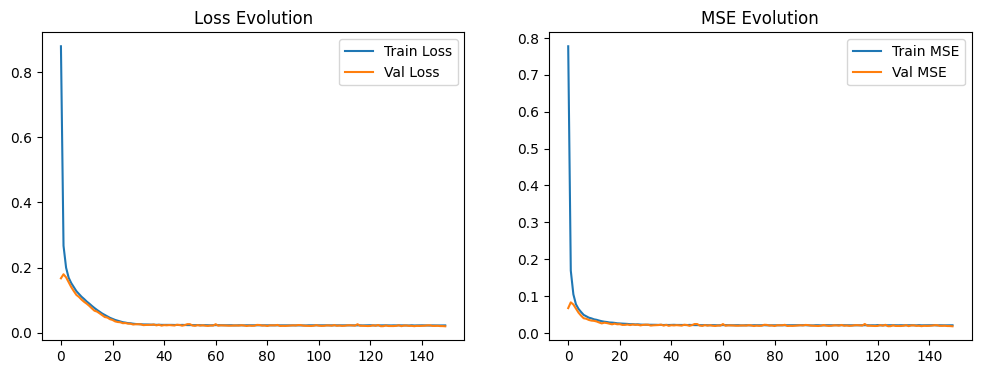

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss Evolution')

plt.subplot(1, 2, 2)
plt.plot(history.history['mse'], label='Train MSE')
plt.plot(history.history['val_mse'], label='Val MSE')
plt.legend()
plt.title('MSE Evolution')
plt.show()

# Prevendo um valor

In [70]:
# Dados de um bairro
imovel_realista = {
    'longitude': -122.25,
    'latitude': 37.85,
    'housing_median_age': 15.0,
    'total_rooms': 1250.0,
    'total_bedrooms': 250.0,
    'population': 1200.0,
    'households': 350.0,
    'median_income': 4.5,
    'ocean_proximity_<1H OCEAN': 0.0,
    'ocean_proximity_INLAND': 0.0,
    'ocean_proximity_ISLAND': 0.0,
    'ocean_proximity_NEAR BAY': 1.0,
    "ocean_proximity_NEAR OCEAN": 0.0
}

new_value = np.array([[-122.25, 37.85, 15.0, 1250.0, 250.0, 1200.0, 350.0, 4.5, 0.0, 0.0, 0.0, 1.0, 0.0]])

In [110]:
new_value_scaled = y_scaler.transform(new_value)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [111]:
tree_new_value = tree.predict(new_value_scaled)
tree_new_value

array([232382.35294118])

In [112]:
random_new_value = random_forest.predict(new_value_scaled)
random_new_value

array([238152.72691534])

In [179]:
boosting_new_value = boosting.predict(new_value_scaled)
boosting_new_value

array([195759.98797595])

In [173]:
mlp_value_scaled = mlp_regressor_scaled.predict(new_value_scaled)
mlp_value = y_scaler.inverse_transform(mlp_value_scaled.reshape(-1, 1))
print(f"Valor previsto CORRETO: ${mlp_value[0][0]:,.2f}")

Valor previsto CORRETO: $198,441.70


In [181]:
deep_value_scaled = regressor.predict(new_value_scaled)
deep_value = y_scaler.inverse_transform(deep_value_scaled.reshape(-1, 1))
print(f"Valor previsto CORRETO: ${deep_value[0][0]:,.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Valor previsto CORRETO: $199,811.58


# Insights:
1. Boosting, MLP e Deep Learning formam um "cluster" de concordância.
2. Árvore e Random Forest são ligeiramente mais otimistas
3. Precisão cruzada: Ótimo sinal quando modelos diferentes convergem

# Modelos mais confiáveis:

Pelos resultados, Boosting, MLP e Deep Learning parecem ser os mais consistentes!

# Conclusão

* **RandomForest** é o algoritmo mais robusto para este problema

* **Normalização** é crucial para redes neurais (MLP)

* **Boosting e DecisionTree** são pouco sensíveis à normalização

* O **RandomForest** seria a escolha recomendada para este conjunto de dados